Data Understanding

In [8]:
# Import the pandas library for data manipulation
import pandas as pd

# Load the dataset into a DataFrame
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

# Display the number of rows and columns in the dataset
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])
print("Dataset Shape:", df.shape)

# Display the first 5 rows of the dataset
print("\nFirst 5 Rows:")
print(df.head())

# Display the last 5 rows of the dataset
print("\nLast 5 Rows:")
print(df.tail())

# Display information about the dataset
print("\nDataset Information:")
df.info()

# Display statistical summary of numerical columns
print("\nStatistical Summary (Numerical Columns):")
print(df.describe())

# Display statistical summary including categorical columns
print("\nStatistical Summary (All Columns):")
print(df.describe(include='all'))

# Display all column names
print("\nColumn Names:")
print(df.columns.tolist())

# Display the data type of each column
print("\nData Types:")
print(df.dtypes)

# Count missing values in each column
print("\nMissing Values in Each Column:")
print(df.isnull().sum())

# Display the total number of missing values
print("\nTotal Missing Values:", df.isnull().sum().sum())

# Count duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())

# Count the number of unique values in each column
print("\nUnique Values in Each Column:")
print(df.nunique())

# Display the number of numerical and categorical columns
print("\nNumber of Numerical Columns:", len(df.select_dtypes(include=['int64', 'float64']).columns))
print("Number of Categorical Columns:", len(df.select_dtypes(include=['object']).columns))

# Display the names of numerical columns
print("\nNumerical Columns:")
print(df.select_dtypes(include=['int64', 'float64']).columns.tolist())

# Display the names of categorical columns
print("\nCategorical Columns:")
print(df.select_dtypes(include=['object']).columns.tolist())

# Display memory usage of the dataset
print("\nMemory Usage of Dataset:")
print(df.memory_usage(deep=True))

# Display the total memory consumed by the dataset
print("\nTotal Memory Usage: {:.2f} KB".format(df.memory_usage(deep=True).sum()/1024))

# Display a complete summary of the dataset
print("\n========== DATASET SUMMARY ==========")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())
print("Numerical Columns:", len(df.select_dtypes(include=['int64', 'float64']).columns))
print("Categorical Columns:", len(df.select_dtypes(include=['object']).columns))
print("====================================")

Number of Rows: 2640
Number of Columns: 12
Dataset Shape: (2640, 12)

First 5 Rows:
   Year  Month         Region    Model  Estimated_Deliveries  \
0  2023      5         Europe  Model S                 17646   
1  2015      2           Asia  Model X                  3797   
2  2019      1  North America  Model X                  8411   
3  2021      2  North America  Model 3                  6555   
4  2016     12    Middle East  Model Y                 12374   

   Production_Units  Avg_Price_USD  Battery_Capacity_kWh  Range_km  \
0             17922       92874.27                   120       704   
1              4164       62205.65                    75       438   
2              9189      117887.32                    82       480   
3              7311       89294.91                   120       712   
4             13537      114846.78                   120       661   

   CO2_Saved_tons           Source_Type  Charging_Stations  
0         1863.42  Interpolated (Month)          

Data Preprocessing

In [9]:
# Import required libraries for preprocessing
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Create a copy of the original dataset
df_processed = df.copy()

# Check the shape of the dataset before preprocessing
print("Dataset Shape Before Preprocessing:", df_processed.shape)

# Verify missing values
print("\nMissing Values Before Preprocessing:")
print(df_processed.isnull().sum())

# Verify duplicate records
print("\nDuplicate Records Before Preprocessing:", df_processed.duplicated().sum())

# Remove duplicate rows if any exist
df_processed.drop_duplicates(inplace=True)

# Reset index after removing duplicates
df_processed.reset_index(drop=True, inplace=True)

# Display categorical columns
categorical_columns = df_processed.select_dtypes(include='object').columns
print("\nCategorical Columns:")
print(categorical_columns.tolist())

# Display numerical columns
numerical_columns = df_processed.select_dtypes(exclude='object').columns
print("\nNumerical Columns:")
print(numerical_columns.tolist())

# Encode categorical variables using Label Encoding
label_encoders = {}

for column in categorical_columns:
    encoder = LabelEncoder()
    df_processed[column] = encoder.fit_transform(df_processed[column])
    label_encoders[column] = encoder

print("\nCategorical Columns Successfully Encoded.")

# Display first five rows after encoding
print("\nFirst Five Rows After Encoding:")
print(df_processed.head())

# Check data types after preprocessing
print("\nData Types After Preprocessing:")
print(df_processed.dtypes)

# Verify that no missing values exist after preprocessing
print("\nMissing Values After Preprocessing:")
print(df_processed.isnull().sum())

# Display the final dataset shape
print("\nDataset Shape After Preprocessing:", df_processed.shape)

# Display the processed dataset information
print("\nProcessed Dataset Information:")
df_processed.info()

Dataset Shape Before Preprocessing: (2640, 12)

Missing Values Before Preprocessing:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Duplicate Records Before Preprocessing: 0

Categorical Columns:
['Region', 'Model', 'Source_Type']

Numerical Columns:
['Year', 'Month', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations']

Categorical Columns Successfully Encoded.

First Five Rows After Encoding:
   Year  Month  Region  Model  Estimated_Deliveries  Production_Units  \
0  2023      5       1      2                 17646             17922   
1  2015      2       0      3                  3797              4164   
2  2019      1       

Exploratory Data Analysis (EDA)

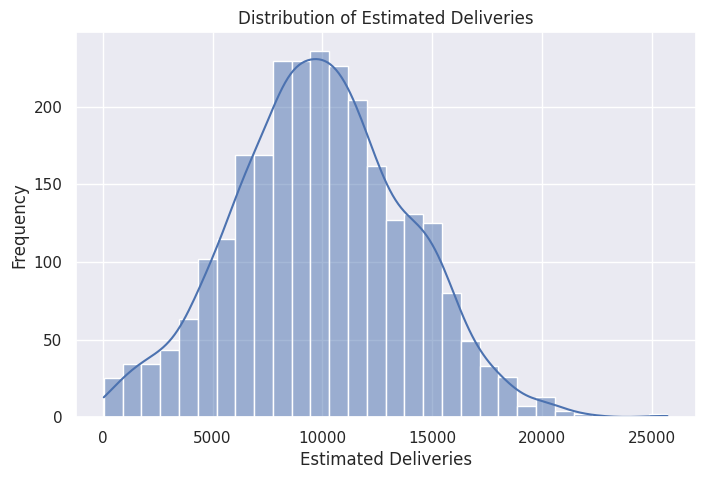

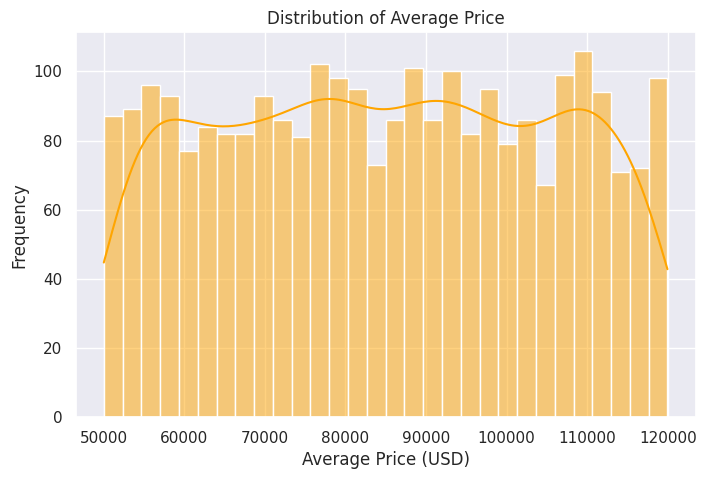

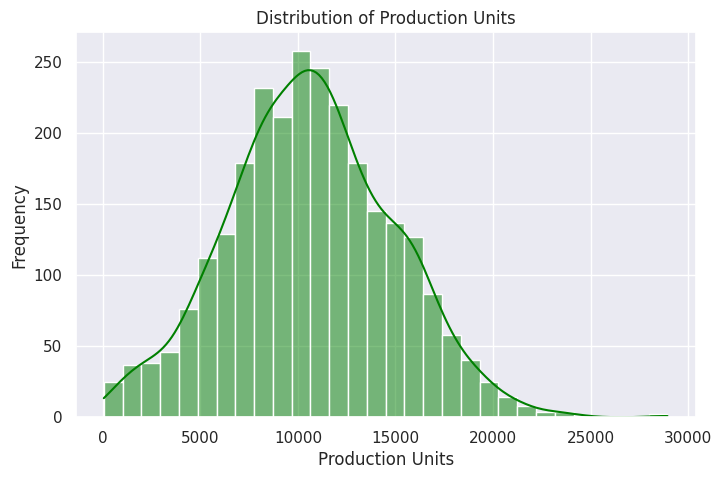

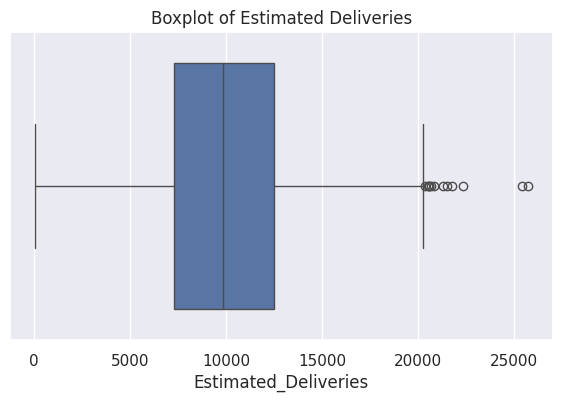

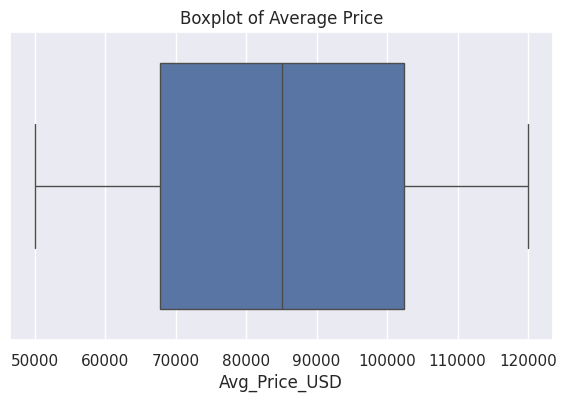

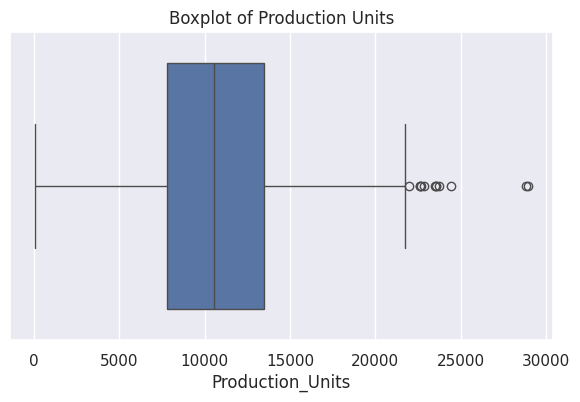

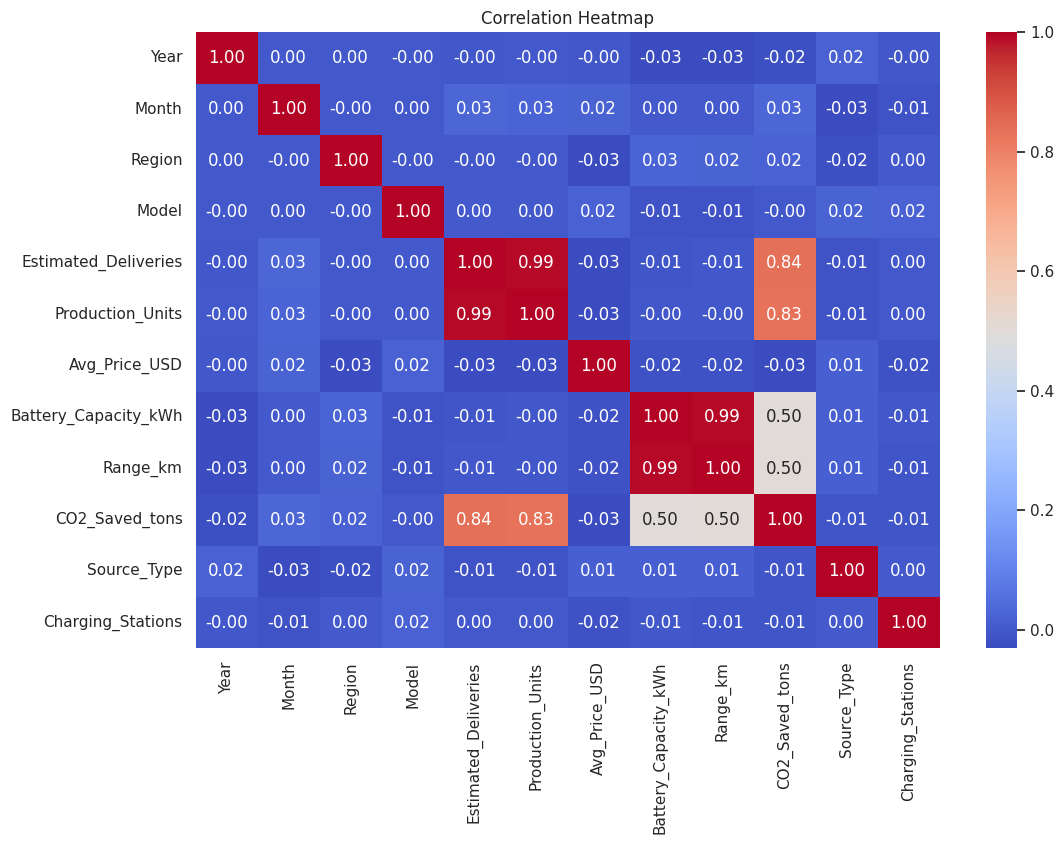

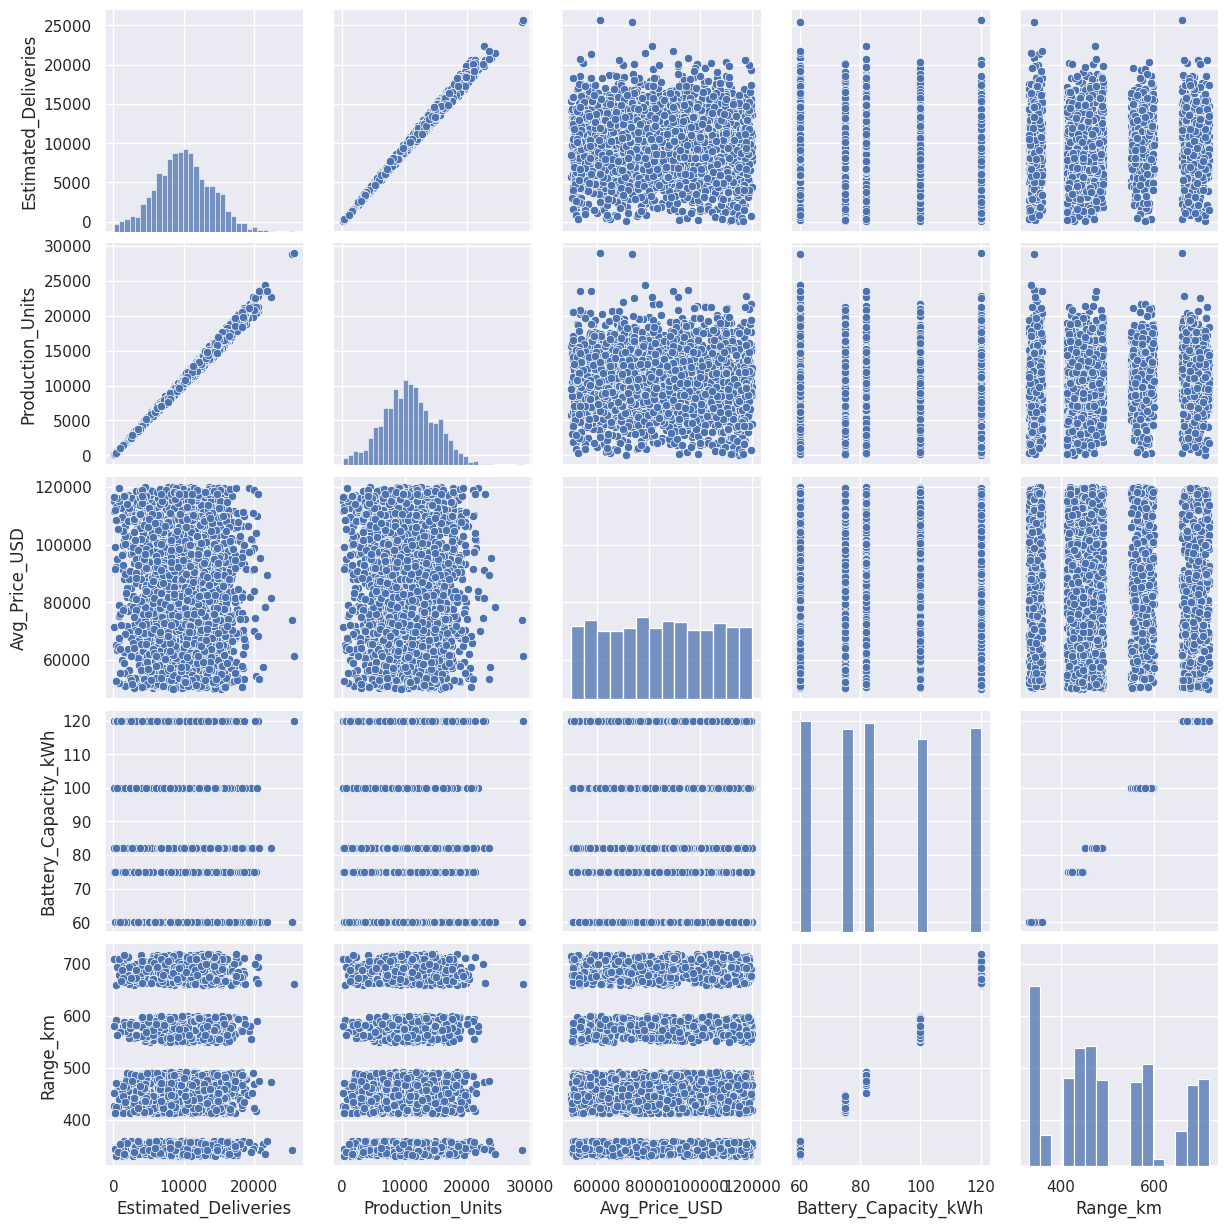

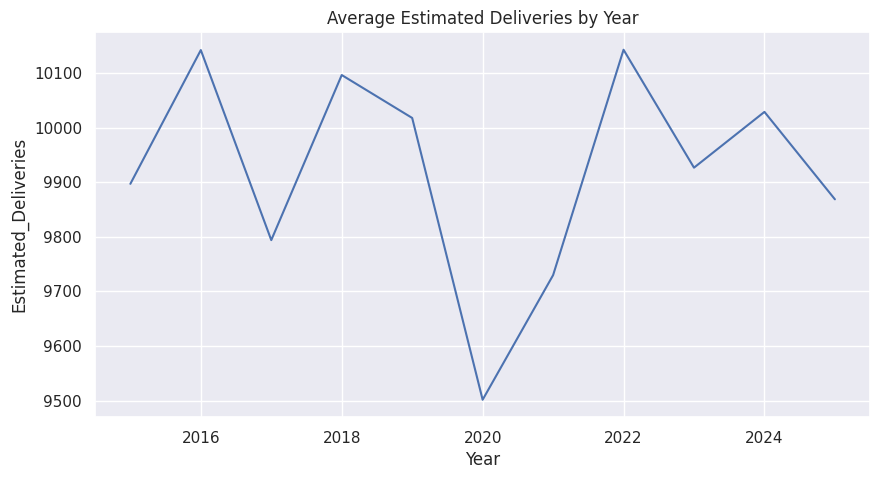

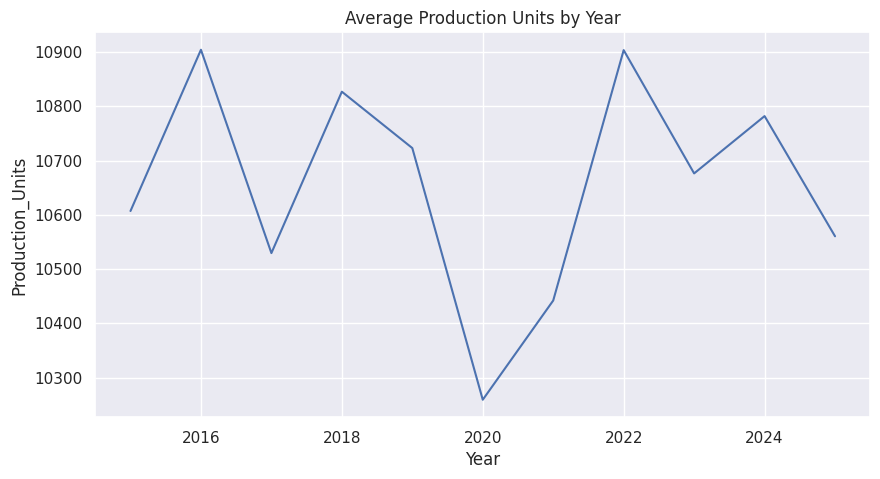

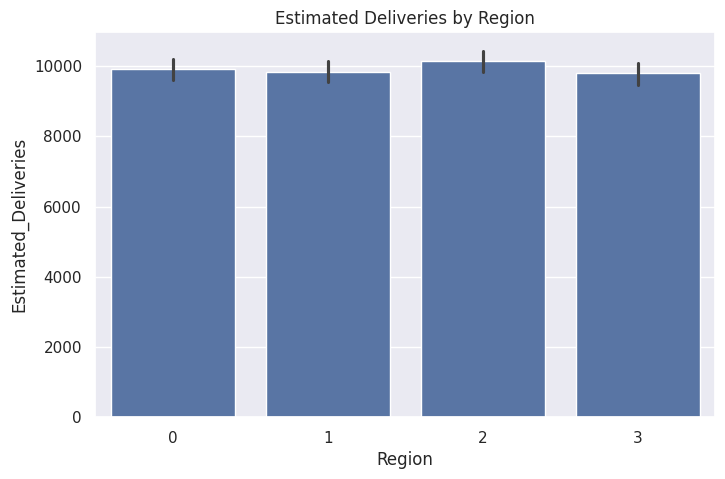

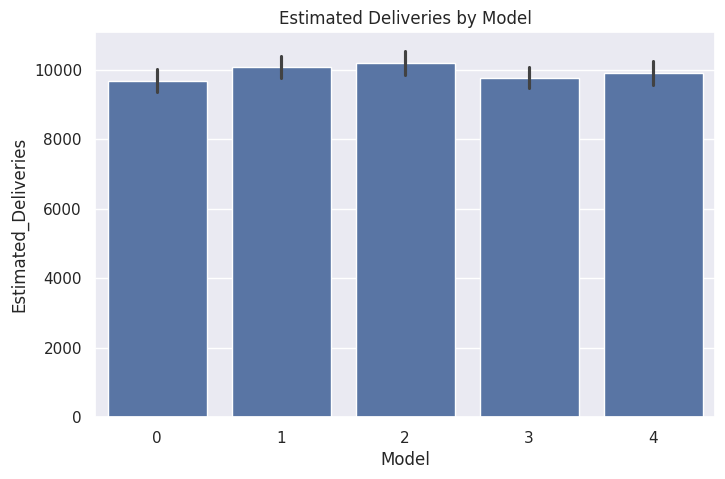

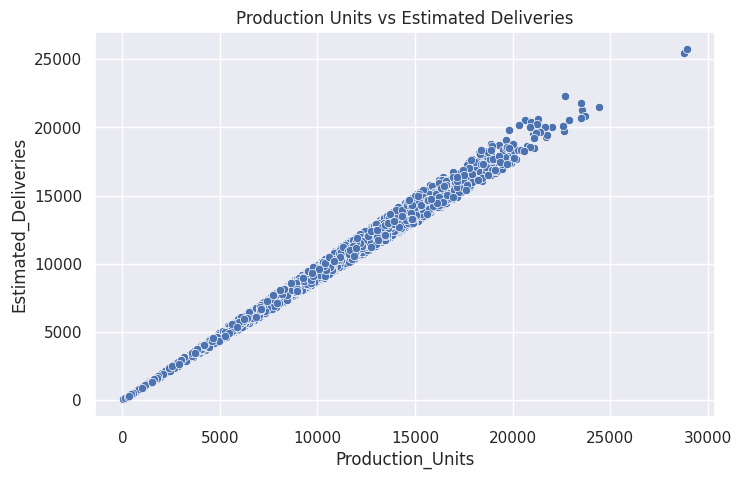

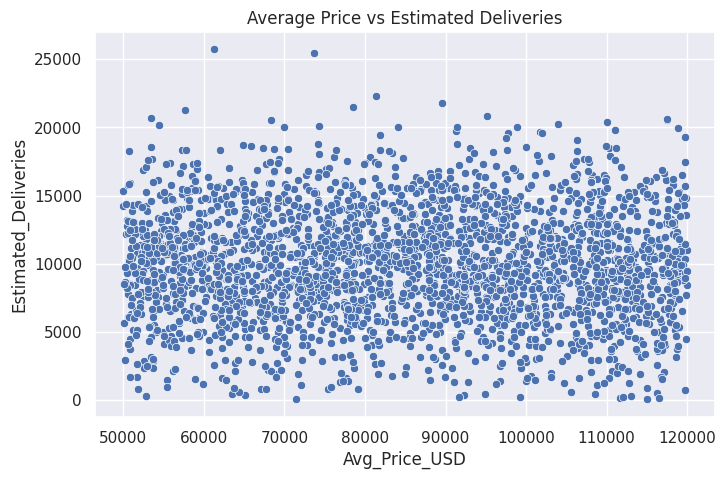

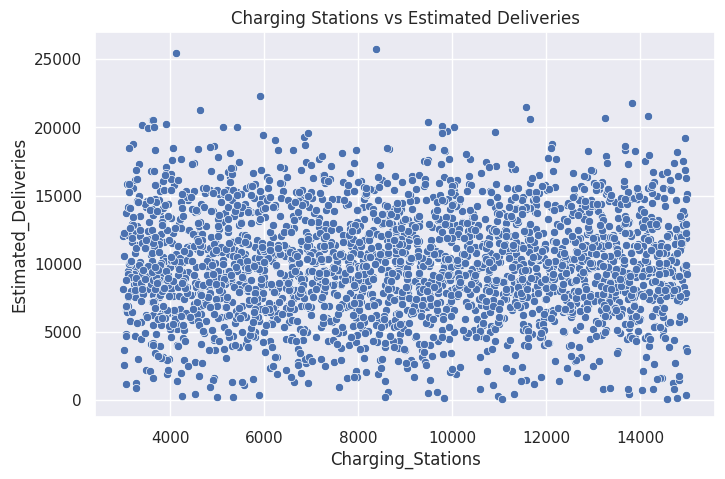

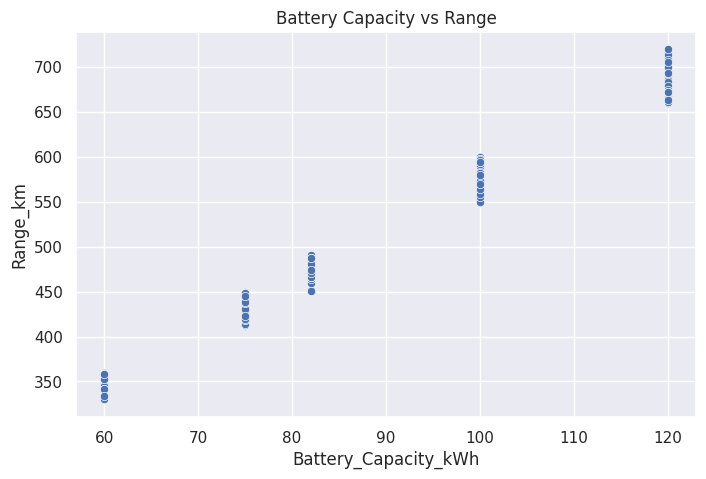

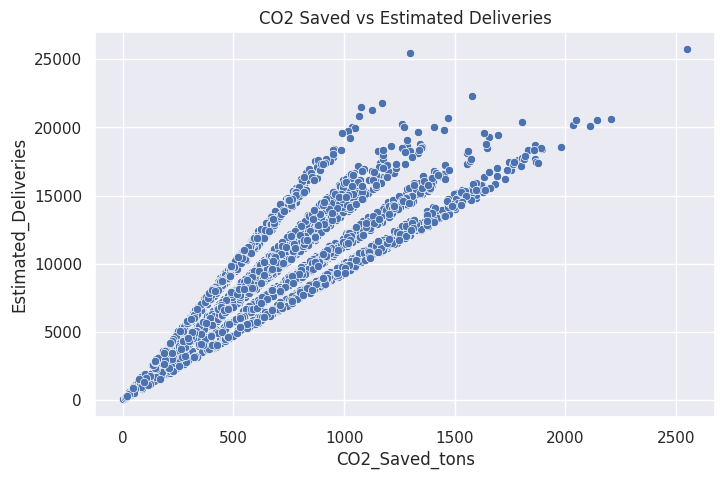

In [10]:
# Import required libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
plt.style.use('ggplot')
sns.set(font_scale=1)

# Distribution of Estimated Deliveries
plt.figure(figsize=(8,5))
sns.histplot(df_processed['Estimated_Deliveries'], bins=30, kde=True)
plt.title("Distribution of Estimated Deliveries")
plt.xlabel("Estimated Deliveries")
plt.ylabel("Frequency")
plt.show()

# Distribution of Average Price
plt.figure(figsize=(8,5))
sns.histplot(df_processed['Avg_Price_USD'], bins=30, kde=True, color='orange')
plt.title("Distribution of Average Price")
plt.xlabel("Average Price (USD)")
plt.ylabel("Frequency")
plt.show()

# Distribution of Production Units
plt.figure(figsize=(8,5))
sns.histplot(df_processed['Production_Units'], bins=30, kde=True, color='green')
plt.title("Distribution of Production Units")
plt.xlabel("Production Units")
plt.ylabel("Frequency")
plt.show()

# Boxplot for Estimated Deliveries
plt.figure(figsize=(7,4))
sns.boxplot(x=df_processed['Estimated_Deliveries'])
plt.title("Boxplot of Estimated Deliveries")
plt.show()

# Boxplot for Average Price
plt.figure(figsize=(7,4))
sns.boxplot(x=df_processed['Avg_Price_USD'])
plt.title("Boxplot of Average Price")
plt.show()

# Boxplot for Production Units
plt.figure(figsize=(7,4))
sns.boxplot(x=df_processed['Production_Units'])
plt.title("Boxplot of Production Units")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df_processed.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# Pairplot of important numerical features
sns.pairplot(df_processed[['Estimated_Deliveries',
                           'Production_Units',
                           'Avg_Price_USD',
                           'Battery_Capacity_kWh',
                           'Range_km']])
plt.show()

# Deliveries by Year
plt.figure(figsize=(10,5))
sns.lineplot(data=df_processed, x='Year', y='Estimated_Deliveries', estimator='mean', errorbar=None)
plt.title("Average Estimated Deliveries by Year")
plt.show()

# Production Units by Year
plt.figure(figsize=(10,5))
sns.lineplot(data=df_processed, x='Year', y='Production_Units', estimator='mean', errorbar=None)
plt.title("Average Production Units by Year")
plt.show()

# Deliveries by Region
plt.figure(figsize=(8,5))
sns.barplot(data=df_processed, x='Region', y='Estimated_Deliveries')
plt.title("Estimated Deliveries by Region")
plt.show()

# Deliveries by Model
plt.figure(figsize=(8,5))
sns.barplot(data=df_processed, x='Model', y='Estimated_Deliveries')
plt.title("Estimated Deliveries by Model")
plt.show()

# Scatter Plot: Production vs Deliveries
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_processed,
                x='Production_Units',
                y='Estimated_Deliveries')
plt.title("Production Units vs Estimated Deliveries")
plt.show()

# Scatter Plot: Average Price vs Deliveries
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_processed,
                x='Avg_Price_USD',
                y='Estimated_Deliveries')
plt.title("Average Price vs Estimated Deliveries")
plt.show()

# Scatter Plot: Charging Stations vs Deliveries
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_processed,
                x='Charging_Stations',
                y='Estimated_Deliveries')
plt.title("Charging Stations vs Estimated Deliveries")
plt.show()

# Scatter Plot: Battery Capacity vs Range
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_processed,
                x='Battery_Capacity_kWh',
                y='Range_km')
plt.title("Battery Capacity vs Range")
plt.show()

# Scatter Plot: CO2 Saved vs Deliveries
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_processed,
                x='CO2_Saved_tons',
                y='Estimated_Deliveries')
plt.title("CO2 Saved vs Estimated Deliveries")
plt.show()

Feature Engineering

In [11]:
# Import numpy library
import numpy as np

# Create a copy of the processed dataset
df_featured = df_processed.copy()

# Create Delivery Efficiency feature
# This represents the ratio of deliveries to production units
df_featured["Delivery_Efficiency"] = (
    df_featured["Estimated_Deliveries"] /
    df_featured["Production_Units"]
)

# Create Price Per Kilometer feature
# This represents the average price per kilometer of range
df_featured["Price_Per_km"] = (
    df_featured["Avg_Price_USD"] /
    df_featured["Range_km"]
)

# Create CO2 Saved Per Delivery feature
# This represents environmental benefit per delivered vehicle
df_featured["CO2_Per_Delivery"] = (
    df_featured["CO2_Saved_tons"] /
    df_featured["Estimated_Deliveries"]
)

# Create Charging Stations Per Delivery feature
df_featured["Charging_Per_Delivery"] = (
    df_featured["Charging_Stations"] /
    df_featured["Estimated_Deliveries"]
)

# Create Battery Efficiency feature
# This represents kilometers obtained per kWh
df_featured["Battery_Efficiency"] = (
    df_featured["Range_km"] /
    df_featured["Battery_Capacity_kWh"]
)

# Display first five rows of engineered features
print("First Five Rows After Feature Engineering:")
print(df_featured.head())

# Display all column names
print("\nUpdated Columns:")
print(df_featured.columns.tolist())

# Display dataset shape
print("\nDataset Shape After Feature Engineering:")
print(df_featured.shape)

# Display statistical summary of new features
print("\nSummary of Engineered Features:")
print(df_featured[
    [
        "Delivery_Efficiency",
        "Price_Per_km",
        "CO2_Per_Delivery",
        "Charging_Per_Delivery",
        "Battery_Efficiency"
    ]
].describe())

First Five Rows After Feature Engineering:
   Year  Month  Region  Model  Estimated_Deliveries  Production_Units  \
0  2023      5       1      2                 17646             17922   
1  2015      2       0      3                  3797              4164   
2  2019      1       3      3                  8411              9189   
3  2021      2       3      1                  6555              7311   
4  2016     12       2      4                 12374             13537   

   Avg_Price_USD  Battery_Capacity_kWh  Range_km  CO2_Saved_tons  Source_Type  \
0       92874.27                   120       704         1863.42            1   
1       62205.65                    75       438          249.46            2   
2      117887.32                    82       480          605.59            1   
3       89294.91                   120       712          700.07            2   
4      114846.78                   120       661         1226.88            0   

   Charging_Stations  Delivery_

Regression Modeling

In [12]:
# Import required libraries
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import pandas as pd
import numpy as np

# Define the target variable
y = df_featured["Estimated_Deliveries"]

# Define the feature variables
X = df_featured.drop(columns=["Estimated_Deliveries"])

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)

# Create a dictionary of regression models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

# Create an empty list to store results
results = []

# Train and evaluate each model
for name, model in models.items():

    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    predictions = model.predict(X_test)

    # Calculate evaluation metrics
    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)

    # Store results
    results.append([name, mae, mse, rmse, r2])

# Create a DataFrame of results
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "MSE",
        "RMSE",
        "R2 Score"
    ]
)

# Display model comparison
print("\nRegression Model Performance")
print(results_df.sort_values(by="R2 Score", ascending=False))

Training Set Shape: (2112, 16)
Testing Set Shape: (528, 16)

Regression Model Performance
               Model         MAE           MSE        RMSE  R2 Score
3  Gradient Boosting   72.464120  10230.882284  101.147824  0.999314
2      Random Forest   69.920909  13288.144345  115.274214  0.999109
0  Linear Regression  108.849066  23477.244126  153.222858  0.998425
1      Decision Tree  118.649621  26708.157197  163.426305  0.998208


Hyperparameter Tuning

In [13]:
# Import GridSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create the Gradient Boosting model
gbr = GradientBoostingRegressor(random_state=42)

# Define the hyperparameter grid
param_grid = {
    "n_estimators": [100, 150, 200],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4],
    "subsample": [0.8, 1.0]
}

# Perform Grid Search with 5-fold Cross Validation
grid_search = GridSearchCV(
    estimator=gbr,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

# Train the model
grid_search.fit(X_train, y_train)

# Best parameters
print("Best Parameters:")
print(grid_search.best_params_)

# Best cross-validation score
print("\nBest Cross Validation R2 Score:")
print(grid_search.best_score_)

# Best model
best_model = grid_search.best_estimator_

# Predict on test data
predictions = best_model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print("\nEvaluation Metrics After Hyperparameter Tuning")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

Best Parameters:
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}

Best Cross Validation R2 Score:
0.9990953893762018

Evaluation Metrics After Hyperparameter Tuning
MAE : 67.22469325089875
MSE : 8061.796074515055
RMSE: 89.78750511354603
R2 Score: 0.9994591681039479


Time Series Forecasting using ARIMA

Average Estimated Deliveries by Year
Year
2015     9896.945833
2016    10142.004167
2017     9793.820833
2018    10096.266667
2019    10017.625000
2020     9501.400000
2021     9729.650000
2022    10142.583333
2023     9926.562500
2024    10028.745833
2025     9868.591667
Name: Estimated_Deliveries, dtype: float64


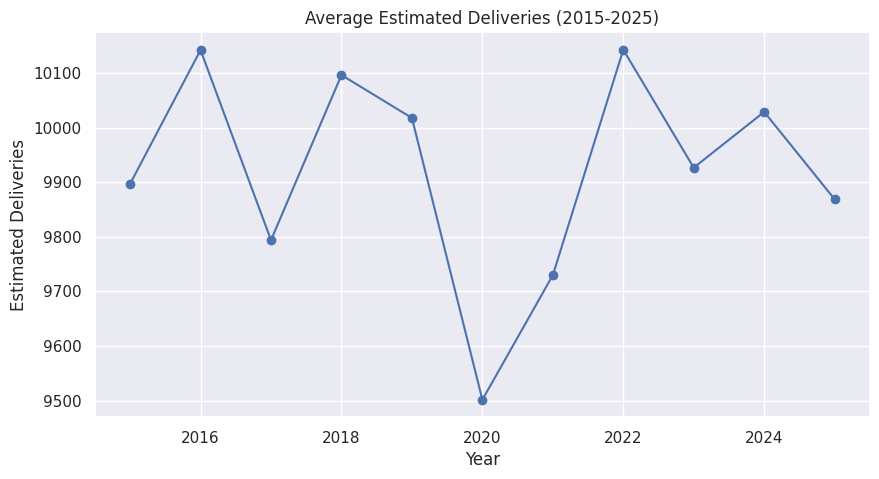

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as s


Forecasted Deliveries
    Year  Forecasted_Deliveries
11  2026            9631.505809
12  2027           10070.769985
13  2028            9981.015241


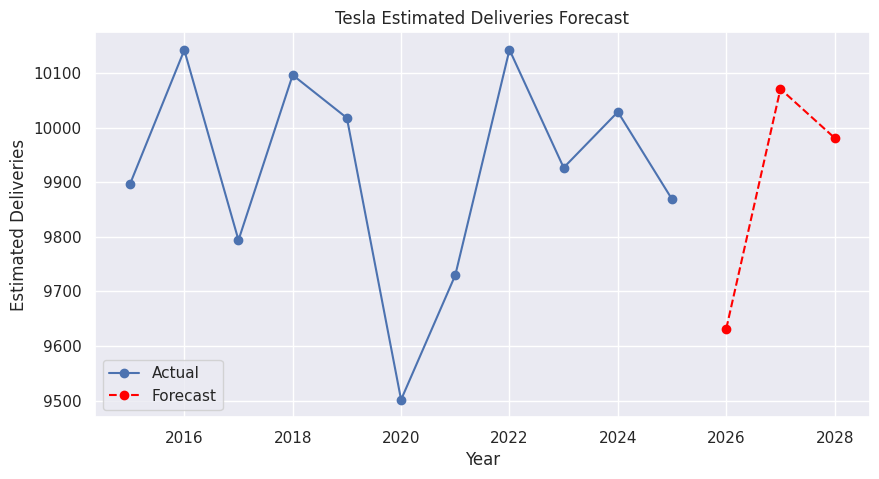

In [14]:
# Import required libraries
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

# Aggregate estimated deliveries by year
time_series = df.groupby("Year")["Estimated_Deliveries"].mean()

# Display the time series
print("Average Estimated Deliveries by Year")
print(time_series)

# Plot the historical data
plt.figure(figsize=(10,5))
plt.plot(time_series.index, time_series.values, marker='o')
plt.title("Average Estimated Deliveries (2015-2025)")
plt.xlabel("Year")
plt.ylabel("Estimated Deliveries")
plt.grid(True)
plt.show()

# Train the ARIMA model
model = ARIMA(time_series, order=(2,1,2))
model_fit = model.fit()

# Forecast next 3 years
forecast = model_fit.forecast(steps=3)

# Forecast years
future_years = [2026, 2027, 2028]

# Display forecast
forecast_df = pd.DataFrame({
    "Year": future_years,
    "Forecasted_Deliveries": forecast
})

print("\nForecasted Deliveries")
print(forecast_df)

# Plot actual vs forecast
plt.figure(figsize=(10,5))

plt.plot(
    time_series.index,
    time_series.values,
    marker='o',
    label="Actual"
)

plt.plot(
    future_years,
    forecast,
    marker='o',
    linestyle='--',
    color='red',
    label="Forecast"
)

plt.title("Tesla Estimated Deliveries Forecast")
plt.xlabel("Year")
plt.ylabel("Estimated Deliveries")
plt.legend()
plt.grid(True)

plt.show()

Save the Model

In [15]:
# Import joblib
import joblib

# Save the best tuned model
joblib.dump(best_model, "best_gradient_boosting_model.pkl")

print("Model saved successfully.")

Model saved successfully.


Feature Importance

                  Feature    Importance
4        Production_Units  9.905105e-01
11    Delivery_Efficiency  9.073027e-03
15     Battery_Efficiency  1.341012e-04
8          CO2_Saved_tons  1.162204e-04
14  Charging_Per_Delivery  5.726265e-05
0                    Year  4.766518e-05
5           Avg_Price_USD  1.987248e-05
10      Charging_Stations  1.267236e-05
12           Price_Per_km  7.447653e-06
1                   Month  7.060436e-06
13       CO2_Per_Delivery  6.457444e-06
9             Source_Type  2.781701e-06
2                  Region  1.956253e-06
3                   Model  1.632802e-06
7                Range_km  1.153947e-06
6    Battery_Capacity_kWh  1.718715e-07


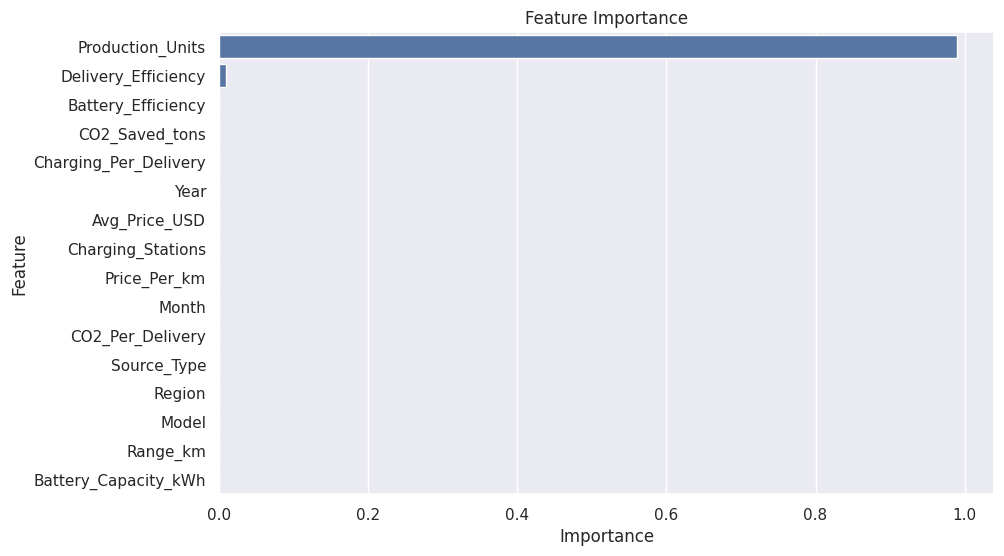

In [16]:
# Create feature importance dataframe
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

# Sort features
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display feature importance
print(feature_importance)

# Plot feature importance
plt.figure(figsize=(10,6))
sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)
plt.title("Feature Importance")
plt.show()

Actual vs Predicted Values

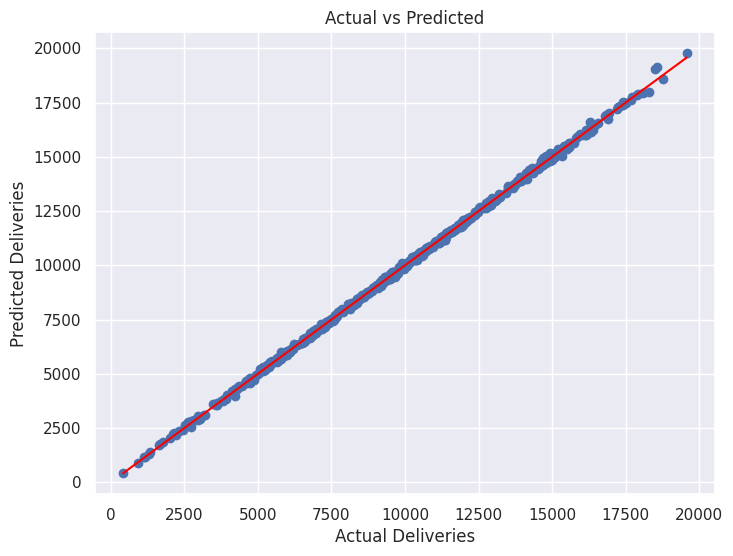

In [17]:
# Predict on test data
predictions = best_model.predict(X_test)

# Plot Actual vs Predicted
plt.figure(figsize=(8,6))

plt.scatter(y_test, predictions)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.xlabel("Actual Deliveries")
plt.ylabel("Predicted Deliveries")
plt.title("Actual vs Predicted")

plt.show()

Final Conclusion
# Conclusion

This project successfully implemented an end-to-end Machine Learning pipeline on the Tesla Deliveries and Production dataset (2015–2025). The workflow included data preprocessing, exploratory data analysis (EDA), feature engineering, regression modeling, hyperparameter tuning, and time series forecasting.

Among the evaluated regression models, the Gradient Boosting Regressor achieved the best performance with an R² score of approximately 0.9995 after hyperparameter tuning, indicating excellent predictive accuracy.

The ARIMA model was used for forecasting estimated deliveries for the next three years (2026–2028), providing insights into future delivery trends.

The trained model was saved for future use, making the project a complete end-to-end machine learning pipeline.